In [51]:
from torch import nn
import torch
import torch.optim as optim
import torch.nn.functional as F

class DownBlock(nn.Module):
    def __init__(self, inp,  out):
        super(DownBlock, self).__init__()

        self.block = nn.Sequential(nn.Conv2d(inp, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(), nn.Conv2d(out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU())

    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, inp,  out, skip=False):
        super(UpBlock, self).__init__()

        self.block = nn.ModuleList([
            nn.Sequential(nn.ConvTranspose2d(inp, out, 2, stride=2), nn.BatchNorm2d(out), nn.ReLU()), 
        nn.Sequential(nn.Conv2d(inp if skip else out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(), nn.Conv2d(out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU())
        ])
        self.skip = skip

    def forward(self, x, skip):
        x = self.block[0](x)
        if self.skip:
            x = torch.concat([x, skip], dim=1)
        x = self.block[1](x)

        return x


class Vanilla(nn.Module):
    def __init__(self, skip=True):
        super(Vanilla, self).__init__()

        self.maxpool = nn.MaxPool2d(2)
        self.skip = skip

        self.downsample = nn.ModuleList([
            DownBlock(3, 64),
            DownBlock(64, 128),
            DownBlock(64*2, 128*2),
            DownBlock(64*4, 128*4),
            DownBlock(64*8, 128*8),
            ])
        
        self.upsample = nn.ModuleList([
            UpBlock(128*8, 64*8, skip=True),
            UpBlock(128*4, 64*4, skip=True),
            UpBlock(128*2, 64*2, skip=True),
            UpBlock(128, 64, skip=True),
            ])
        
        self.conv2d = nn.Conv2d(64, 14, 1)

    def forward(self, x):
        hidden_out = []
        for i, down in enumerate(self.downsample):
            x = down(x)
            hidden_out.append(x.clone())
            if i == len(self.downsample) - 1:
                continue
            x = self.maxpool(x)

        hidden_out.pop()
        for up in self.upsample:
            skip = hidden_out.pop()
            x = up(x, skip)

        x = self.conv2d(x)
        seg_x = x[:, :13, :, :]
        dep_x = F.relu(x[:, 13:, :, :])
        return torch.concat([seg_x, dep_x], 1)

net = Vanilla(skip=True)
sample = torch.rand(1, 3, 256, 256)
out = net(sample)
out.shape

torch.Size([1, 14, 256, 256])

In [2]:
sample = nn.ConvTranspose2d(1024, 512, 3, padding=8, stride=3)
sample = nn.ConvTranspose2d(1024, 512, 2, stride=2)
# sample = nn.Conv2d(1024, 1024, 3, padding=1)
sample(torch.rand(1, 1024, 16, 16)).shape

torch.Size([1, 512, 32, 32])

In [3]:
import cv2

seg_label = cv2.imread(f"segdepth/train/labels/02_00_000.png")
depth_label = cv2.imread(f"segdepth/train/depth/02_00_000.png")

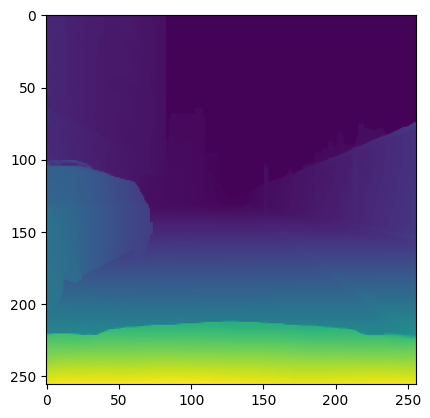

In [4]:
import matplotlib.pyplot as plt
plt.imshow(depth_label[:, :, 2])

In [5]:
seg_label[1][2]

array([0, 0, 1], dtype=uint8)

In [6]:
import numpy as np
# Define your 15 colors as RGB triplets (+1 for index 0/background)
palette = np.array([
    [0,   0,   0],      # 0: Background (Black)
    [255, 0,   0],      # 1: Red
    [0,   255, 0],      # 2: Green
    [0,   0,   255],     # 3: Blue
    [255, 255, 0],      # 4: Yellow
    [255, 0,   255],    # 5: Magenta
    [0,   255, 255],    # 6: Cyan
    [255, 165, 0],      # 7: Orange
    [128, 0,   128],    # 8: Purple
    [165, 42,   42],    # 9: Brown
    [255, 192, 203],    # 10: Pink
    [50,  205, 50],     # 11: Lime
    [0,   128, 128],    # 12: Teal
], dtype=np.uint8)
seg = np.zeros_like(seg_label)
last = seg_label[:, :, 2]
for i in range(256):
    for j in range(256):
        color = palette[seg_label[i][j][2]]
        for k in range(3):
            seg[i][j][k] = color[k]

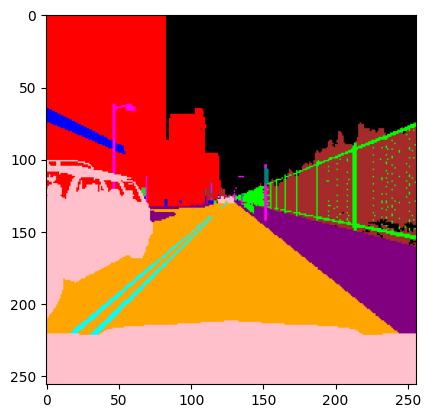

In [7]:
plt.imshow(seg)

In [8]:
import os
files = os.listdir(f"segdepth/train/labels/")
unq = set()
for file in files:
    seg_label = cv2.imread(f"segdepth/train/labels/{file}")
    print(np.unique(seg_label[:, :, 2]))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  7  8  9 10]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  2  4  5  6  7  8  9 10]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  2  3  5  6  7  8  9 10 12]
[ 0  1  2  3  5  6  7  8  9 10 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  2  6  7  8  9 10]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  7  8  9 10]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  2  6  7  8  9 10]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  1  3  5  6  7  8  9 10 11 12]
[ 0  1  2  3  5  6  7  8  9 10 11 12]
[ 0  2  5  6  7  8  9 10]
[ 0  1  2  3  4  5  

In [9]:
from torch.utils.data import Dataset, DataLoader

class SegDepth(Dataset):
    def __init__(self, mode='train'):
        self.images = []
        self.seg = []
        self.depth = []

        files = os.listdir(f"segdepth/{mode}/images/")
        for file in files:
            image = cv2.imread(f"segdepth/{mode}/images/{file}")
            self.images.append(torch.tensor(image).permute(2, 0, 1))

            label = cv2.imread(f"segdepth/{mode}/labels/{file}")
            temp = np.zeros((256, 256, 13))

            for i in range(256):
                for j in range(256):
                    temp[i][j][label[i][j][2]] = 1.0
            self.seg.append(temp)
            
            label = cv2.imread(f"segdepth/{mode}/depth/{file}")
            temp = np.zeros((256, 256, 1))
            for i in range(256):
                for j in range(256):
                    temp[i][j][0] = float(label[i][j][0])
            self.depth.append(temp)
    
    def __getitem__(self, i):
        return self.images[i], self.seg[i], self.depth[i]

    def __len__(self):
        return len(self.images)

train = SegDepth('train')

In [10]:
train.__len__()

2000

In [11]:
train_loader = DataLoader(train, batch_size=16, shuffle=True)

In [58]:
net = Vanilla(skip=True).to("cuda")

In [54]:
net = Vanilla(skip=False).to("cuda")

In [64]:
net = Vanilla(skip=True).to("cuda")

In [65]:
segloss = nn.CrossEntropyLoss()
deploss = nn.MSELoss()
opt = optim.Adam(net.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    segepoch_loss = 0
    depepoch_loss = 0
    for (inp, seglabel, deplabel) in train_loader:
        opt.zero_grad()
        inp = inp.to("cuda").to(torch.float32)
        seglabel = torch.tensor(seglabel).to("cuda").to(torch.float32)
        deplabel = torch.tensor(deplabel).to("cuda").to(torch.float32)

        out = net(inp)
        # print(out.permute(0, 2, 3, 1).shape, seglabel.shape, deplabel.shape)
        loss1 = segloss(out[:, :13], seglabel.argmax(-1))
        loss2 = deploss(out[:, 13:].permute(0, 2, 3, 1), deplabel)
        loss = loss1 + loss2
        loss.backward()

        opt.step()
        segepoch_loss += loss1
        depepoch_loss += loss2
    
    print(f"Seg Loss at epoch {epoch+1} is {segepoch_loss/len(train_loader)}")
    print(f"Dep Loss at epoch {epoch+1} is {depepoch_loss/len(train_loader)}")

        

/tmp/ipykernel_1329996/2024578580.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seglabel = torch.tensor(seglabel).to("cuda").to(torch.float32)
/tmp/ipykernel_1329996/2024578580.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  deplabel = torch.tensor(deplabel).to("cuda").to(torch.float32)


Seg Loss at epoch 1 is 1.6190106868743896
Dep Loss at epoch 1 is 7791.91064453125
Seg Loss at epoch 2 is 1.1428121328353882
Dep Loss at epoch 2 is 6665.40234375
Seg Loss at epoch 3 is 1.0687549114227295
Dep Loss at epoch 3 is 5255.2646484375
Seg Loss at epoch 4 is 1.180166244506836
Dep Loss at epoch 4 is 3624.00537109375
Seg Loss at epoch 5 is 1.2076878547668457
Dep Loss at epoch 5 is 1848.172119140625
Seg Loss at epoch 6 is 1.3752660751342773
Dep Loss at epoch 6 is 553.0615844726562
Seg Loss at epoch 7 is 1.2975027561187744
Dep Loss at epoch 7 is 124.82006072998047
Seg Loss at epoch 8 is 1.034313440322876
Dep Loss at epoch 8 is 66.534423828125
Seg Loss at epoch 9 is 0.8782494068145752
Dep Loss at epoch 9 is 58.5240592956543
Seg Loss at epoch 10 is 0.8241979479789734
Dep Loss at epoch 10 is 54.03618621826172
Seg Loss at epoch 11 is 0.8049637079238892
Dep Loss at epoch 11 is 58.333709716796875
Seg Loss at epoch 12 is 0.7577759623527527
Dep Loss at epoch 12 is 51.623870849609375
Seg Loss

In [74]:
test = SegDepth('test')
test_loader = DataLoader(test, batch_size=1, shuffle=True)

ev = 0
for (inp, seglabel, deplabel) in test_loader:
    opt.zero_grad()
    inp = inp.to("cuda").to(torch.float32)
    seglabel = torch.tensor(seglabel).to("cuda").to(torch.float32)
    deplabel = torch.tensor(deplabel).to("cuda").to(torch.float32)

    out = net(inp)
    loss2 = deploss(out[:, 13:].permute(0, 2, 3, 1), deplabel)
    ev += loss2.item()
    
ev/len(test_loader)

/tmp/ipykernel_1329996/2120087636.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  seglabel = torch.tensor(seglabel).to("cuda").to(torch.float32)
/tmp/ipykernel_1329996/2120087636.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  deplabel = torch.tensor(deplabel).to("cuda").to(torch.float32)


75.14563504600525

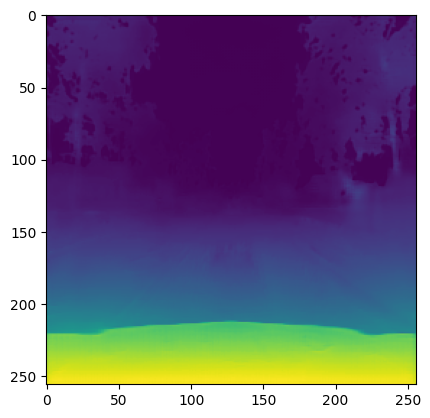

In [78]:
plt.imshow(out[:, 13:].permute(0, 2, 3, 1).to(int)[0].cpu().numpy())

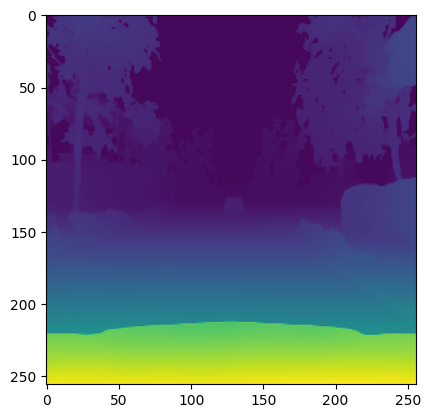

In [79]:
plt.imshow(deplabel.to(int).cpu().numpy()[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


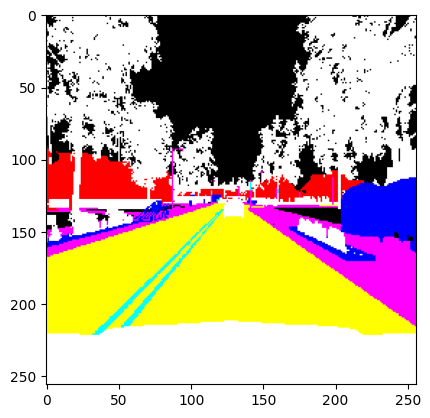

In [80]:
temp = np.zeros((256, 256, 3))
for i in range(256):
    for j in range(256):
        temp[i][j] = palette[torch.argmax(seglabel[0, :, :], -1)[i][j]]

plt.imshow(temp)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


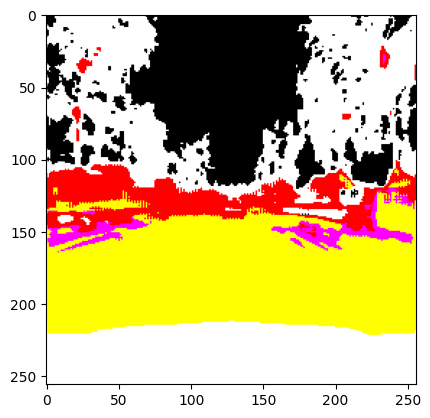

In [81]:
temp = np.zeros((256, 256, 3))
for i in range(256):
    for j in range(256):
        temp[i][j] = palette[torch.argmax(out[0, :13], 0)[i][j]]
plt.imshow(temp)

In [ ]:
test = SegDepth('test')
test_loader = DataLoader(test, batch_size=1, shuffle=True)

ev = 0
for (inp, seglabel, deplabel) in test_loader:
    opt.zero_grad()
    inp = inp.to("cuda").to(torch.float32)
    seglabel = torch.tensor(seglabel).to("cuda").to(torch.float32)

    out = net(inp)
    
ev/len(test_loader)

In [ ]:
del net
torch.cuda.empty_cache()